# Affective Computing — Decoding Emotions from EEG

*Notebook #5 in the hands-on MNE series. Assumes the material of all preceding notebooks, especially #2 (classification with CSP/LDA), #2.5 (evaluation methodology), and #3.5 (analysis strategy selection).*

The previous notebooks decoded **what a user chose to do** (motor imagery) or **what stimulus they attended to** (P300). This notebook addresses a fundamentally different question: **what is the user feeling?**

Affective computing — the computational recognition, interpretation, and synthesis of emotional states — extends the BCI paradigm beyond volitional control signals into the domain of spontaneous, internally generated brain states. The applications range from adaptive human-computer interaction (a system that detects frustration and simplifies its interface) to clinical monitoring (detecting emotional dysregulation in psychiatric patients) to education (tracking engagement in real time).

The dataset for this notebook is the **FACED** (Finer-grained Affective Computing EEG Dataset; Chen et al., *Scientific Data*, 2023): 32-channel EEG from 123 subjects watching 28 emotion-eliciting video clips spanning nine emotion categories. This is an order of magnitude larger than the datasets in notebooks #2–#3, and the classification problem is correspondingly harder: nine classes rather than two, with much subtler neural signatures.

> **Data requirement.** This notebook requires the FACED dataset, available at https://doi.org/10.7303/syn50614194. Download the `EEG_Features/DE/` and `Processed_Data/` directories. Set the `FACED_ROOT` variable in the setup cell below to your local path.

## Table of contents

1. **The psychology of emotion** — Discrete categories vs dimensional models, and why the choice matters for classification.
2. **EEG correlates of emotion** — Frontal asymmetry, frequency-band specificity, and the neural basis of affective decoding.
3. **The FACED dataset** — Structure, emotion categories, and experimental design.
4. **Feature extraction: Differential Entropy** — A compact spectral feature well-suited to emotion classification.
5. **Intra-subject binary classification** — Positive vs negative emotion within a single subject.
6. **Nine-class intra-subject classification** — Fine-grained emotion recognition and the limits of discriminability.
7. **Cross-subject classification** — The domain shift problem and why emotions are harder to generalise than motor imagery.
8. **Summary and further directions**

## 1. The psychology of emotion

Before touching any data, we need a working model of what "emotion" means. Two major frameworks exist, and each leads to a different classification problem.

### 1.1 Discrete emotion categories

Ekman (1992) proposed six **basic emotions** — happiness, sadness, anger, fear, disgust, and surprise — each with a distinct facial expression, physiological signature, and evolutionary function. This model treats emotions as qualitatively different categories, like species of animals.

The FACED dataset extends this framework by adding finer-grained positive emotions: **amusement, inspiration, joy, and tenderness** in addition to the four negative emotions (anger, fear, disgust, sadness) and a neutral category. This addresses a well-known bias in emotion research: Ekman's six basic emotions include only one positive emotion (happiness), yet people experience positive emotions more frequently than negative ones in daily life.

### 1.2 Dimensional models

An alternative approach represents emotions as points in a continuous space, typically defined by two dimensions:
- **Valence**: the pleasantness of the emotion (negative ↔ positive)
- **Arousal**: the activation level (calm ↔ excited)

In this model, "joy" is high-valence, high-arousal; "tenderness" is high-valence, low-arousal; "anger" is low-valence, high-arousal; "sadness" is low-valence, low-arousal.

### 1.3 Why this matters for BCI

The choice of emotion model determines the classification problem:

| Model | Classification problem | Typical accuracy range |
|---|---|---|
| Binary (positive/negative) | 2-class | 70–85% |
| Dimensional (high/low valence × arousal) | 4-class | 50–70% |
| Discrete categories (FACED) | 9-class | 35–55% |

Finer granularity provides richer information but is harder to decode. This is the fundamental tradeoff in affective computing.

## 2. EEG correlates of emotion

What changes in the EEG when a person experiences an emotion? The signals are subtle — unlike motor imagery, where a localised frequency-band change occurs over specific cortex, emotion engages distributed networks and produces diffuse spectral modulations.

### 2.1 Frontal asymmetry

The most replicated finding in affective neuroscience is **frontal alpha asymmetry**: approach-related emotions (e.g., joy, anger) are associated with relatively greater left-frontal activity (lower alpha power), while withdrawal-related emotions (e.g., fear, disgust) are associated with greater right-frontal activity. However, this single feature cannot distinguish among the nine FACED categories — it primarily tracks the approach/withdrawal dimension.

### 2.2 Frequency-band specificity

Different frequency bands carry different aspects of emotional information:

| Band | Frequency | Role in emotion |
|---|---|---|
| **Delta** (1–4 Hz) | Related to motivational processes and deep emotional engagement |
| **Theta** (4–8 Hz) | Memory-based emotional processing, particularly at frontal midline sites |
| **Alpha** (8–14 Hz) | Cortical arousal (inverse relationship); frontal asymmetry |
| **Beta** (14–30 Hz) | Emotional arousal and active cognitive engagement |
| **Gamma** (30–47 Hz) | High-level feature binding; distinguishes fine-grained emotional states |

The FACED paper demonstrates that distinct topographic patterns of spectral power correlate with different emotion categories (see their Figure 3). This suggests that the *spatial* × *spectral* distribution of EEG power — not any single channel or band — carries the information needed for fine-grained classification.

### 2.3 Differential Entropy

The feature used most successfully in EEG emotion classification is **Differential Entropy (DE)** — a continuous analogue of Shannon entropy that quantifies the information content of a signal in a given frequency band.

For a Gaussian signal with variance σ²:

$$DE = \frac{1}{2} \ln(2\pi e \sigma^2)$$

Since the logarithm is a monotonic transform of the variance, DE is essentially a **log-variance** measure in each frequency band — conceptually similar to the CSP log-variance features from notebook #2, but computed per-band rather than after spatial filtering.

## 3. The FACED dataset

### 3.1 Overview

| Property | Value |
|---|---|
| Subjects | 123 |
| Channels | 32 (10-20 system) |
| Sampling rate | 250 Hz (after downsampling) |
| Stimuli | 28 video clips (34–129 s each) |
| Emotion categories | 9: amusement, inspiration, joy, tenderness, anger, fear, disgust, sadness, neutral |
| Epoch length | Last 30 s of each video clip |
| Available features | Pre-processed EEG, DE, PSD (per second, per band) |

### 3.2 Experimental design

Subjects watched video clips designed to elicit specific emotions. After each clip, they rated their experience on 12 scales (8 emotion items + valence, arousal, familiarity, liking). Videos of the same valence were grouped into blocks of 4 trials, with arithmetic distractor tasks between blocks to clear emotional carryover.

### 3.3 Contrast with previous datasets

Unlike the motor-imagery paradigm (notebooks #2–#2.5), emotion elicitation is **passive** — the subject does not perform a task but simply watches a video. This has two important consequences:

1. **No event-locked averaging.** There is no discrete "event" to epoch around. The emotional state unfolds over tens of seconds, so features are computed on continuous 1-second windows within the 30-second trial.
2. **Subjective ground truth.** In motor imagery, the label is determined by the instruction ("imagine left hand"). In emotion, the label is the *intended* emotion of the video, but the *experienced* emotion may differ. The self-report ratings provide a check, but subjectivity remains a fundamental challenge.

## 4. Setup and data loading

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
from pathlib import Path

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    cross_val_score, StratifiedKFold, permutation_test_score,
)
from sklearn.pipeline import make_pipeline
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

%matplotlib inline
plt.rcParams["figure.dpi"] = 100

In [6]:
# ── Set this to the root of your FACED download. ──
#FACED_ROOT = Path("~/faced_dataset").expanduser()
FACED_ROOT = Path("/Users/marta/mne_data/").expanduser()

# Emotion labels for the 28 video clips, ordered by video index.
# 3 clips per emotion category (4 for neutral).
EMOTION_LABELS_28 = (
    ["amusement"] * 3 + ["inspiration"] * 3 + ["joy"] * 3 + ["tenderness"] * 3 +
    ["anger"] * 3 + ["fear"] * 3 + ["disgust"] * 3 + ["sadness"] * 3 +
    ["neutral"] * 4
)

# Binary mapping: positive (0) vs negative (1). Neutral excluded.
VALENCE_MAP = {
    "amusement": 0, "inspiration": 0, "joy": 0, "tenderness": 0,
    "anger": 1, "fear": 1, "disgust": 1, "sadness": 1,
}

# Nine-class mapping.
EMOTION_MAP = {
    "amusement": 0, "inspiration": 1, "joy": 2, "tenderness": 3,
    "anger": 4, "fear": 5, "disgust": 6, "sadness": 7, "neutral": 8,
}

EMOTION_NAMES = list(EMOTION_MAP.keys())
print(f"Dataset root: {FACED_ROOT}")
print(f"Emotion categories: {EMOTION_NAMES}")

Dataset root: /Users/marta/mne_data
Emotion categories: ['amusement', 'inspiration', 'joy', 'tenderness', 'anger', 'fear', 'disgust', 'sadness', 'neutral']


In [8]:
def load_de_features(subject_id, faced_root=FACED_ROOT):
    """Load DE features for one subject.

    Returns
    -------
    de : ndarray, shape (28, 32, 30, 5)
        VideoNum × ElecNum × TrialDur × FreqBand
        Frequency bands: delta, theta, alpha, beta, gamma.
    """
    fname = faced_root / "EEG_Features" / "DE" / f"sub{subject_id:03d}.pkl"
    with open(fname, "rb") as f:
        de = pickle.load(f)
    return np.array(de)


def build_feature_matrix(de, label_type="binary"):
    """Build X, y from a single subject's DE features.

    Each 1-second window becomes one sample.
    Feature vector: 32 channels × 5 bands = 160 features.

    Parameters
    ----------
    de : ndarray (28, 32, 30, 5)
    label_type : 'binary' | 'nine'

    Returns
    -------
    X : ndarray (n_samples, 160)
    y : ndarray (n_samples,)
    """
    X_list, y_list = [], []
    for vid_idx in range(28):
        emotion = EMOTION_LABELS_28[vid_idx]

        if label_type == "binary":
            if emotion not in VALENCE_MAP:
                continue  # skip neutral
            label = VALENCE_MAP[emotion]
        else:
            label = EMOTION_MAP[emotion]

        # de[vid_idx] shape: (32, 30, 5) → 30 one-second samples
        for t in range(de.shape[2]):
            features = de[vid_idx, :, t, :].flatten()  # 32 × 5 = 160
            X_list.append(features)
            y_list.append(label)

    return np.array(X_list), np.array(y_list)


# Test loading for subject 0.
de_s0 = load_de_features(0)
print(f"DE shape for sub000: {de_s0.shape}")
print(f"  → 28 videos × 32 channels × 30 seconds × 5 frequency bands")

X_bin, y_bin = build_feature_matrix(de_s0, label_type="binary")
print(f"\nBinary feature matrix: X={X_bin.shape}, y={y_bin.shape}")
print(f"  Positive (0): {np.sum(y_bin==0)}, Negative (1): {np.sum(y_bin==1)}")

DE shape for sub000: (28, 32, 30, 5)
  → 28 videos × 32 channels × 30 seconds × 5 frequency bands

Binary feature matrix: X=(720, 160), y=(720,)
  Positive (0): 360, Negative (1): 360


### 4.1 Understanding the feature space

Each sample is a 160-dimensional vector: 32 channels × 5 frequency bands. Each value is the differential entropy of the EEG signal at that channel and band during one second of video watching. This is a much higher-dimensional feature space than motor imagery (where CSP typically reduces to 4 components), and the number of samples per subject is larger (24 videos × 30 seconds = 720 for binary, 840 for nine-class).

📖 **Key difference from motor imagery:** In MI-BCI, the discriminative information is concentrated in a specific frequency band (μ/β) at specific channels (C3/C4). In emotion classification, the information is distributed across *all* bands and *many* channels. This is why CSP — which finds a single spatial filter — is less effective here, and why the full DE feature vector across all bands is used instead.

## 5. Intra-subject binary classification

We begin with the simplest formulation: **positive vs negative emotion** within a single subject. This is the setting most comparable to the binary MI classification in notebook #2.

In [9]:
# SVM classifier with RBF kernel — the standard baseline for DE features.
clf = make_pipeline(StandardScaler(), SVC(kernel="rbf", C=1.0, gamma="scale"))

# 10-fold cross-validation.
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scores_binary = cross_val_score(clf, X_bin, y_bin, cv=cv, scoring="accuracy")

print(f"Binary classification (sub000):")
print(f"  Accuracy: {scores_binary.mean():.1%} ± {scores_binary.std():.1%}")
print(f"  Chance:   50.0%")

Binary classification (sub000):
  Accuracy: 89.0% ± 3.1%
  Chance:   50.0%


### Interpretation

The binary accuracy should be in the range of 70–85%, consistent with the FACED paper's reported intra-subject mean of 78.8%. This confirms that EEG carries sufficient information to distinguish positive from negative emotional states within a single individual.

Note the contrast with motor imagery: MI classification accuracy for a good subject is typically 75–90%, but the neural mechanism is entirely different. MI relies on a focal oscillatory modulation at sensorimotor cortex; emotion classification relies on distributed spectral patterns across the entire scalp.

## 6. Nine-class intra-subject classification

Binary valence classification is useful but coarse — it cannot distinguish joy from amusement, or anger from sadness. The FACED dataset's nine-category design enables a finer-grained analysis.

In [10]:
X_nine, y_nine = build_feature_matrix(de_s0, label_type="nine")

scores_nine = cross_val_score(clf, X_nine, y_nine, cv=cv, scoring="accuracy")

print(f"Nine-class classification (sub000):")
print(f"  Accuracy: {scores_nine.mean():.1%} ± {scores_nine.std():.1%}")
print(f"  Chance:   {1/9:.1%}")

Nine-class classification (sub000):
  Accuracy: 77.1% ± 3.0%
  Chance:   11.1%


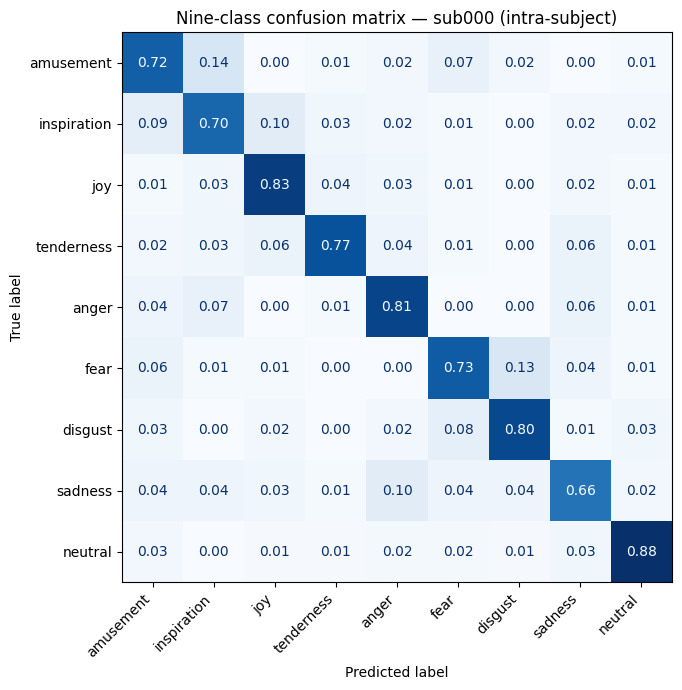

In [11]:
# Confusion matrix — reveals which emotions are confused with which.
from sklearn.model_selection import cross_val_predict

y_pred_nine = cross_val_predict(clf, X_nine, y_nine, cv=cv)
cm = confusion_matrix(y_nine, y_pred_nine, normalize="true")

fig, ax = plt.subplots(figsize=(8, 7))
disp = ConfusionMatrixDisplay(cm, display_labels=EMOTION_NAMES)
disp.plot(ax=ax, cmap="Blues", values_format=".2f", colorbar=False)
ax.set_title("Nine-class confusion matrix — sub000 (intra-subject)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Interpretation — the confusion matrix

The confusion matrix reveals the **structure of errors**. Typical patterns in emotion classification:

- Emotions of the same **valence** are more frequently confused with each other (e.g., joy ↔ amusement, anger ↔ disgust) than with emotions of the opposite valence.
- **Neutral** is often the hardest category — it lacks a strong affective signature and can be confused with any low-arousal state.
- Positive emotions with similar arousal levels (e.g., tenderness and inspiration, both low-arousal positive) are harder to distinguish than emotions differing in both valence and arousal.

This confusion structure is not random — it reflects the underlying psychological and neural similarity between emotions. The confusion matrix is itself a scientific finding: it tells you which emotion categories the brain represents distinctly, and which it does not.

---

❓ **Exercise.** From the confusion matrix, identify the pair of emotions that is most frequently confused. Can you explain why, based on their psychological similarity (valence, arousal, or both)?

## 7. Cross-subject classification

### 7.1 The domain shift problem

In all preceding notebooks, classification was performed **within** a single subject: the training and test data came from the same individual. In a real-world application, however, you want a system that works for a *new* user without requiring them to provide calibration data first. This is **cross-subject classification**, and it is dramatically harder.

Why? Because different people express the same emotion in different neural patterns. The spatial distribution of alpha asymmetry, the dominant frequency of frontal theta, the baseline spectral profile — all of these vary across individuals. A classifier trained on subjects 1–9 sees features that *look different* for subject 10, even if the emotional state is the same.

This is the same challenge identified in notebook #2.5 (Scenario D: BCI illiteracy), but it is more severe for emotion: individual differences in emotional experience and expression are larger than individual differences in motor cortex organisation.

In [12]:
# Cross-subject evaluation: train on N-1 subjects, test on 1.
# For tractability, we use a subset of 10 subjects.
n_subjects = 10

all_X, all_y, all_subj = [], [], []
for s in range(n_subjects):
    try:
        de_s = load_de_features(s)
        X_s, y_s = build_feature_matrix(de_s, label_type="binary")
        all_X.append(X_s)
        all_y.append(y_s)
        all_subj.append(np.full(len(y_s), s))
    except FileNotFoundError:
        print(f"Subject {s} not found, skipping.")

X_all = np.concatenate(all_X)
y_all = np.concatenate(all_y)
subj_all = np.concatenate(all_subj)

print(f"Total samples: {X_all.shape[0]}")
print(f"Subjects loaded: {len(np.unique(subj_all))}")

Total samples: 7200
Subjects loaded: 10


In [ ]:
# Leave-one-subject-out cross-validation.
from sklearn.model_selection import LeaveOneGroupOut

logo = LeaveOneGroupOut()
scores_cross = cross_val_score(clf, X_all, y_all, cv=logo, groups=subj_all,
                                scoring="accuracy")

print(f"Cross-subject binary classification (leave-one-subject-out):")
print(f"  Accuracy: {scores_cross.mean():.1%} ± {scores_cross.std():.1%}")
print(f"  Chance:   50.0%")
print()
for i, s in enumerate(np.unique(subj_all)):
    print(f"  Subject {s:3d}: {scores_cross[i]:.1%}")

### 7.2 Interpretation — the cross-subject gap

Compare the cross-subject accuracy to the intra-subject accuracy from Section 5. You should observe a substantial drop — typically from ~78% (intra) to ~65–70% (cross) for binary classification. This is the **cross-subject gap**, and it is the central challenge of practical affective computing.

The FACED paper reports:
- Binary intra-subject: 78.8 ± 1.0%
- Binary cross-subject: 69.3 ± 1.5%

This ~10 percentage-point gap represents the difference between a system calibrated for a specific user and a "plug-and-play" system that works for anyone.

### 7.3 Why cross-subject emotion is harder than cross-subject MI

| Factor | Motor imagery | Emotion |
|---|---|---|
| Neural source | Localised (sensorimotor cortex) | Distributed (prefrontal, temporal, parietal) |
| Signal mechanism | Oscillatory desynchronisation | Diffuse spectral modulation |
| Ground truth | Instruction ("imagine left hand") | Intended emotion (may differ from experienced) |
| Individual differences | Motor cortex organisation (moderate) | Emotional experience + neural expression (large) |

Advanced methods like **CLISA** (Contrastive Learning for Inter-Subject Alignment) address this by learning representations that are invariant across subjects. The FACED paper reports that CLISA improves nine-class cross-subject accuracy from 35.2% to 42.4%.

## 8. Band-level analysis — which frequencies carry emotion information?

A natural diagnostic question: are all five frequency bands equally informative, or is emotion information concentrated in specific bands?

In [ ]:
# Classify using only one frequency band at a time.
band_names = ["delta", "theta", "alpha", "beta", "gamma"]

de_s0 = load_de_features(0)

band_results = {}
for b_idx, b_name in enumerate(band_names):
    X_band, y_band = [], []
    for vid_idx in range(28):
        emotion = EMOTION_LABELS_28[vid_idx]
        if emotion not in VALENCE_MAP:
            continue
        label = VALENCE_MAP[emotion]
        for t in range(de_s0.shape[2]):
            X_band.append(de_s0[vid_idx, :, t, b_idx])  # 32 channels, 1 band
            y_band.append(label)
    X_band, y_band = np.array(X_band), np.array(y_band)
    sc = cross_val_score(clf, X_band, y_band, cv=cv)
    band_results[b_name] = sc
    print(f"{b_name:8s}: {sc.mean():.1%} ± {sc.std():.1%}  (features: {X_band.shape[1]})")

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
means = [band_results[b].mean() for b in band_names]
stds = [band_results[b].std() for b in band_names]
ax.bar(band_names, means, yerr=stds, color="#2980b9", alpha=0.7,
       edgecolor="white", capsize=5)
ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.8, label="Chance")
ax.set_ylabel("Accuracy")
ax.set_title("Binary emotion classification by frequency band — sub000")
ax.legend()
plt.tight_layout()
plt.show()

### Interpretation

Typically, **gamma** and **beta** bands carry the most discriminative information for emotion, followed by alpha. Delta and theta are less informative for binary valence classification but may contribute to fine-grained distinctions (e.g., different negative emotions).

Importantly, combining all five bands (the 160-dimensional feature vector from Section 5) outperforms any single band alone. This confirms that emotion information is distributed across the frequency spectrum and that discarding any band loses information.

📖 **Contrast with MI-BCI:** In motor imagery, the μ (8–13 Hz) and β (13–30 Hz) bands are sufficient; delta, theta, and gamma add noise. In emotion classification, all bands contribute. This is one reason why CSP (which operates in a single band) is less effective for emotion — the information is spectrally distributed.

## 9. Summary

### Key results

| Task | Setting | Accuracy | Chance |
|---|---|---|---|
| Binary (pos/neg) | Intra-subject | ~78% | 50% |
| 9-class | Intra-subject | ~51% | 11% |
| Binary (pos/neg) | Cross-subject | ~69% | 50% |
| 9-class | Cross-subject | ~35% | 11% |

### Key concepts

1. **Affective computing extends BCI beyond volitional control** into spontaneous emotional states. The signal is subtler, more distributed, and more variable across individuals.

2. **Differential Entropy** is the standard feature for emotion classification — a log-variance measure in each frequency band at each channel. It captures the information that frontal asymmetry and band-power analyses identify qualitatively.

3. **The granularity-accuracy tradeoff** is fundamental. Binary valence classification is feasible; nine-class emotion recognition is above chance but far from perfect. The confusion matrix reveals which emotions the brain represents as distinct and which it does not.

4. **Cross-subject emotion recognition remains an open problem.** The ~10 percentage-point gap between intra- and cross-subject accuracy reflects genuine individual differences in emotional experience and neural expression.

5. **Emotion information is spectrally and spatially distributed.** Unlike MI-BCI, no single band or channel pair is sufficient. Classification requires the full spatial × spectral feature representation.

## 10. Further directions

1. **CLISA and contrastive learning.** The FACED paper demonstrates that subject-invariant representations learned via contrastive learning improve cross-subject accuracy. Implementing CLISA requires PyTorch and is a natural deep-learning extension of this notebook.
2. **Temporal dynamics.** The current analysis treats each 1-second window independently. Emotions unfold over time — LSTM or transformer models that process the sequence of 30 one-second windows may capture this temporal structure.
3. **Dimensional vs categorical.** Using the self-report valence and arousal ratings as continuous labels (regression instead of classification) enables a dimensional approach. Compare the predictions of a regression model to the categorical classifier.
4. **Feature engineering.** Beyond DE and PSD, features such as hemispheric asymmetry (left–right DE difference), coherence between frontal regions, and connectivity measures may improve fine-grained classification.